In [102]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import LinearRegression


In [103]:
ticker_symbol = "AAPL"
stock = yf.Ticker(ticker_symbol)
df =  stock.history(period= "2y")

In [104]:
stock

yfinance.Ticker object <AAPL>

In [105]:
df

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2024-04-25 00:00:00-04:00,168.001034,169.071296,166.633475,168.357788,50558300,0.0,0.0
2024-04-26 00:00:00-04:00,168.347888,169.794712,167.654189,167.773117,44838400,0.0,0.0
2024-04-29 00:00:00-04:00,171.806409,174.442423,171.538855,171.935242,68169400,0.0,0.0
2024-04-30 00:00:00-04:00,171.766798,173.411830,168.466828,168.793854,65934800,0.0,0.0
2024-05-01 00:00:00-04:00,168.050591,171.152367,167.584828,167.773117,50383100,0.0,0.0
...,...,...,...,...,...,...,...
2026-04-20 00:00:00-04:00,270.329987,274.279999,270.290009,273.049988,36590200,0.0,0.0
2026-04-21 00:00:00-04:00,271.500000,272.799988,265.399994,266.170013,50209800,0.0,0.0
2026-04-22 00:00:00-04:00,267.820007,273.739990,266.869995,273.170013,43249200,0.0,0.0


In [106]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 501 entries, 2024-04-25 00:00:00-04:00 to 2026-04-24 00:00:00-04:00
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          501 non-null    float64
 1   High          501 non-null    float64
 2   Low           501 non-null    float64
 3   Close         501 non-null    float64
 4   Volume        501 non-null    int64  
 5   Dividends     501 non-null    float64
 6   Stock Splits  501 non-null    float64
dtypes: float64(6), int64(1)
memory usage: 31.3 KB


In [107]:
df.columns.tolist()

['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits']

In [108]:
df["target_next_close"] = df["Close"].shift(-1)
df.dropna(inplace=True)
df["target_next_close"]

Date
2024-04-25 00:00:00-04:00    167.773117
2024-04-26 00:00:00-04:00    171.935242
2024-04-29 00:00:00-04:00    168.793854
2024-04-30 00:00:00-04:00    167.773117
2024-05-01 00:00:00-04:00    171.469498
                                ...    
2026-04-17 00:00:00-04:00    273.049988
2026-04-20 00:00:00-04:00    266.170013
2026-04-21 00:00:00-04:00    273.170013
2026-04-22 00:00:00-04:00    273.429993
2026-04-23 00:00:00-04:00    271.059998
Name: target_next_close, Length: 500, dtype: float64

In [109]:
features = ["Open", "Close", "High", "Low", "Volume"]
x = df[features]
y = df["target_next_close"]


In [110]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 27, shuffle = False)

## Random Forest Regression

In [111]:
model = RandomForestRegressor(n_estimators=100, random_state=9)
model.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [112]:
predictions = model.predict(x_test)
predictions

array([254.65354614, 251.3307869 , 247.94931961, 251.85128967,
       254.73840652, 255.27301926, 253.68229996, 253.75661301,
       250.07807602, 246.72498734, 255.20024323, 254.72423004,
       256.57950119, 260.45894211, 251.20367691, 259.95497513,
       259.50157455, 260.61339142, 260.62234894, 258.63186462,
       267.10390045, 262.46853607, 271.77607697, 272.1658905 ,
       267.85104675, 273.43473267, 271.73205963])

In [113]:
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
print(f"mean square error: {mse:.3f}")
print(f"mean absolute error: {mae:.3f}")

mean square error: 16.801
mean absolute error: 3.160


Random Forest Regression


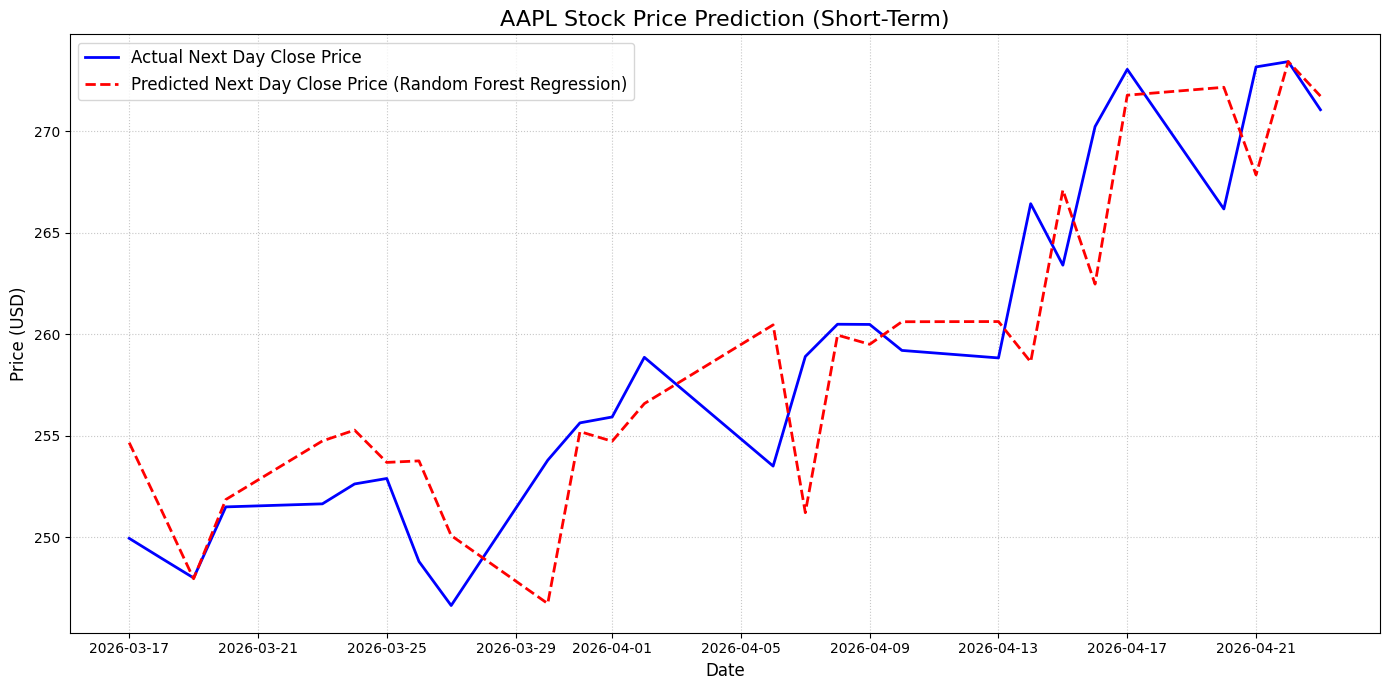

In [114]:
print("Random Forest Regression")
fig, ax = plt.subplots(figsize=(14,7))
ax.plot(y_test.index, y_test.values, label= "Actual Next Day Close Price", color= "blue", linewidth= 2) 
ax.plot(y_test.index, predictions, label='Predicted Next Day Close Price (Random Forest Regression)', color= 'red', linestyle= '--', linewidth= 2)

ax.set_title(f'{ticker_symbol} Stock Price Prediction (Short-Term)', fontsize=16)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Price (USD)', fontsize=12)
ax.legend(loc='upper left', fontsize=12)
ax.grid(True, linestyle=':', alpha=0.7)

fig.tight_layout()
plt.show()

## Linear Regression

In [115]:
linear_model = LinearRegression() 
linear_model.fit(x_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [116]:
linear_predictions = linear_model.predict(x_test)
linear_predictions

array([253.91952238, 249.75806607, 248.76322739, 247.86087374,
       251.39639131, 251.24320449, 252.41809926, 252.4860782 ,
       248.77398428, 246.65046936, 253.57289444, 255.31410514,
       256.02063174, 258.27308699, 254.32334339, 258.6436872 ,
       260.39972909, 260.0239623 , 259.06685367, 258.44145166,
       266.09211384, 263.30017842, 269.55215917, 272.34282168,
       265.88586587, 272.69747496, 273.00041039])

In [117]:
mae = mean_absolute_error(y_test, linear_predictions)
mse = mean_squared_error(y_test, linear_predictions)
print(f"mean square error: {mse:.3f}")
print(f"mean absolute error: {mae:.3f}")

mean square error: 14.404
mean absolute error: 2.938


Linear Regression


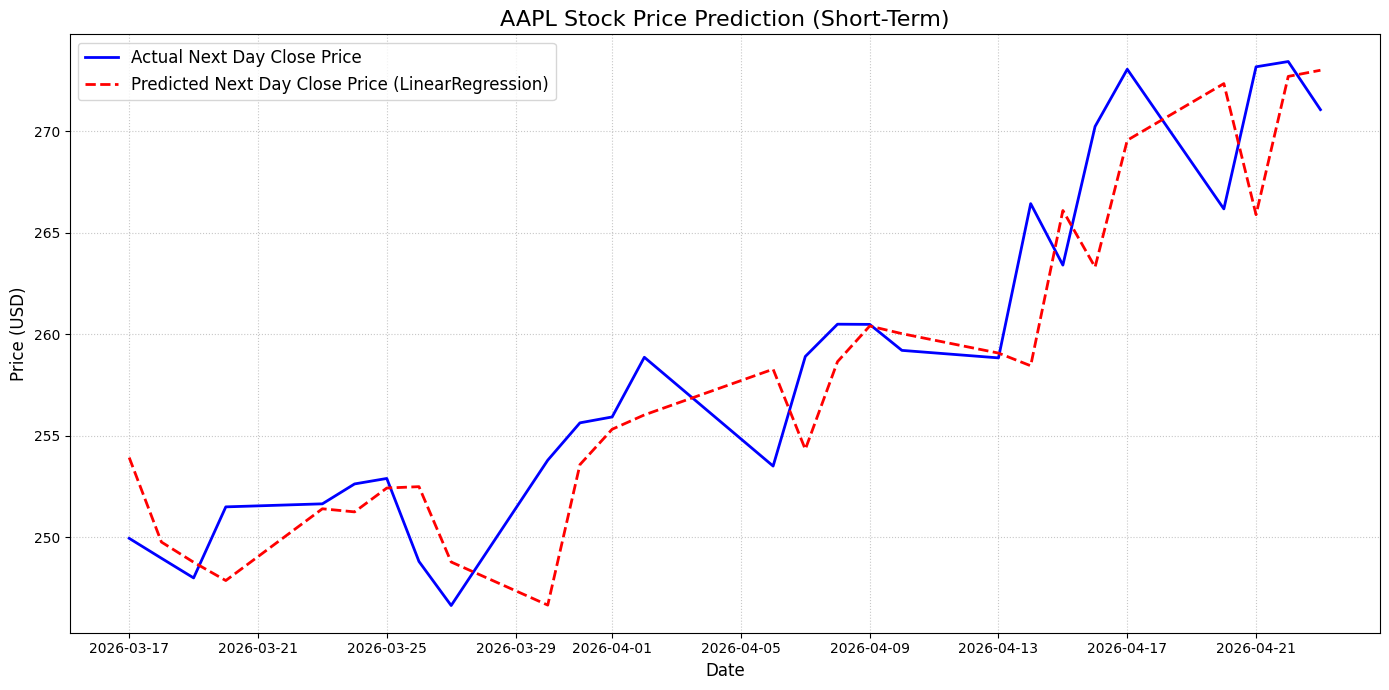

In [118]:
print("Linear Regression")
fig, ax = plt.subplots(figsize=(14,7))
ax.plot(y_test.index, y_test.values, label= "Actual Next Day Close Price", color= "blue", linewidth= 2) 
ax.plot(y_test.index, linear_predictions, label='Predicted Next Day Close Price (LinearRegression)', color= 'red', linestyle= '--', linewidth= 2)

ax.set_title(f'{ticker_symbol} Stock Price Prediction (Short-Term)', fontsize=16)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Price (USD)', fontsize=12)
ax.legend(loc='upper left', fontsize=12)
ax.grid(True, linestyle=':', alpha=0.7)

fig.tight_layout()

plt.show()